# IndabaX Botswana Hackathon 2026
## Forecasting Botswana's Food Price Inflation Under Global Economic Shocks

### Notebook 03: Classical Model — XGBoost

**Purpose:** Builds, trains, and validates XGBoost classical model, also runs a seasonal naive baseline model 

**Input:** `data/processed/modelling_table_with_lags.csv`
**Output:** `generated graphs`

In [1]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import os

## Version 1

In [2]:
# ------------------------------------------------------------
# 1. Load + sanity checks
# ------------------------------------------------------------
df = pd.read_csv('../data/processed/modelling_table_with_lags.csv', parse_dates=['year_month'])

print("Shape:", df.shape)
print("Duplicate year_month rows:", df['year_month'].duplicated().sum())
assert df['year_month'].duplicated().sum() == 0, "STOP: duplicate keys — fix upstream merge first"

df = df.sort_values('year_month').reset_index(drop=True)

target_col = 'target_food_price_inflation'
exog_cols = [
    'hcp_zaf_fao_cp_23014_lag12',
    'brent_yoy_pct_lag12',
    'brent_usd_per_barrel_lag12',
    'policy_rate_lag12',
    'bdi_close_mean_lag12',
    'month_sin',
    'month_cos'
]

before = df.shape[0]
df_clean = df.dropna(subset=exog_cols + [target_col]).reset_index(drop=True)
print(f"Dropped {before - df_clean.shape[0]} rows to NaNs (expect ~12)")


Shape: (276, 264)
Duplicate year_month rows: 0
Dropped 12 rows to NaNs (expect ~12)


In [3]:
# ------------------------------------------------------------
# 2. Three-way split: train / val / holdout
#    Train: used for hyperparameter search
#    Val (2021-2022): used to pick/report the final model
#    Holdout (2023): checked ONCE at the end, never tuned against
# ------------------------------------------------------------
train   = df_clean[(df_clean['year_month'] >= '2001-01-01') & (df_clean['year_month'] <= '2020-12-31')].reset_index(drop=True)
val     = df_clean[(df_clean['year_month'] >= '2021-01-01') & (df_clean['year_month'] <= '2022-12-31')].reset_index(drop=True)
holdout = df_clean[(df_clean['year_month'] >= '2023-01-01') & (df_clean['year_month'] <= '2023-12-31')].reset_index(drop=True)

print("Train:", train.shape, train['year_month'].min(), train['year_month'].max())
print("Val:", val.shape, val['year_month'].min(), val['year_month'].max())
print("Holdout:", holdout.shape, holdout['year_month'].min(), holdout['year_month'].max())

Train: (228, 264) 2002-01-01 00:00:00 2020-12-01 00:00:00
Val: (24, 264) 2021-01-01 00:00:00 2022-12-01 00:00:00
Holdout: (12, 264) 2023-01-01 00:00:00 2023-12-01 00:00:00


In [4]:
# ------------------------------------------------------------
# 3. Seasonal naive baseline (for comparison)
# ------------------------------------------------------------
naive_lookup = df_clean.set_index('year_month')[target_col]
naive_preds = [naive_lookup.loc[dt - pd.DateOffset(years=1)] for dt in val['year_month']]

naive_rmse = np.sqrt(mean_squared_error(val[target_col], naive_preds))
naive_mae = mean_absolute_error(val[target_col], naive_preds)
print(f"\nNaive val RMSE: {naive_rmse:.4f}  MAE: {naive_mae:.4f}")



Naive val RMSE: 6.0882  MAE: 5.1261


In [5]:
# ------------------------------------------------------------
# 4. Hyperparameter search — TimeSeriesSplit CV on TRAIN only
# ------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.5, 1.0],
    'reg_lambda': [1.0, 2.0]
}

base_model = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    base_model,
    param_grid,
    n_iter=50,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(train[exog_cols], train[target_col])

print("\nBest params:", random_search.best_params_)
print("Best CV RMSE (train, internal):", -random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV RMSE (train, internal): 4.909819043035742


In [6]:
# ------------------------------------------------------------
# 5. Refit final model with best params on TRAIN, evaluate on VAL
# ------------------------------------------------------------
final_model = XGBRegressor(**random_search.best_params_, random_state=42)
final_model.fit(train[exog_cols], train[target_col])

val_preds = final_model.predict(val[exog_cols])
val_rmse = np.sqrt(mean_squared_error(val[target_col], val_preds))
val_mae = mean_absolute_error(val[target_col], val_preds)
print(f"\n2021-2022 VAL RMSE: {val_rmse:.4f}  MAE: {val_mae:.4f}")


2021-2022 VAL RMSE: 4.4683  MAE: 3.9963


In [7]:
# 6. Final sanity check — 2023 holdout (report only, no tuning after this)
# ------------------------------------------------------------
holdout_preds = final_model.predict(holdout[exog_cols])
holdout_rmse = np.sqrt(mean_squared_error(holdout[target_col], holdout_preds))
holdout_mae = mean_absolute_error(holdout[target_col], holdout_preds)
print(f"2023 HOLDOUT RMSE: {holdout_rmse:.4f}  MAE: {holdout_mae:.4f}")

2023 HOLDOUT RMSE: 7.3052  MAE: 6.1925


In [8]:
# ------------------------------------------------------------
# 7. Residual diagnostics on VAL predictions
# ------------------------------------------------------------
residuals = val[target_col].values - val_preds
print("\nResiduals (val period):")
for dt, r in zip(val['year_month'], residuals):
    print(dt.strftime('%Y-%m'), f"{r:.3f}")


Residuals (val period):
2021-01 0.959
2021-02 1.087
2021-03 3.570
2021-04 3.242
2021-05 8.775
2021-06 3.320
2021-07 3.390
2021-08 3.325
2021-09 2.621
2021-10 3.372
2021-11 3.495
2021-12 4.724
2022-01 4.363
2022-02 4.050
2022-03 -0.722
2022-04 -4.767
2022-05 -4.883
2022-06 2.028
2022-07 4.567
2022-08 4.186
2022-09 4.259
2022-10 4.012
2022-11 8.298
2022-12 7.897


In [9]:
# ------------------------------------------------------------
# 8. Feature importance
# ------------------------------------------------------------
importance = pd.Series(final_model.feature_importances_, index=exog_cols).sort_values(ascending=False)
print("\nFeature importance:")
print(importance)


Feature importance:
policy_rate_lag12             0.461029
bdi_close_mean_lag12          0.350447
brent_usd_per_barrel_lag12    0.123360
brent_yoy_pct_lag12           0.034819
hcp_zaf_fao_cp_23014_lag12    0.020446
month_cos                     0.008138
month_sin                     0.001759
dtype: float32


In [10]:
# ------------------------------------------------------------
# 9. Summary
# ------------------------------------------------------------
print("\n=== SUMMARY ===")
print(f"Naive:        RMSE {naive_rmse:.4f}  MAE {naive_mae:.4f}")
print(f"XGBoost val:  RMSE {val_rmse:.4f}  MAE {val_mae:.4f}")
print(f"XGBoost 2023: RMSE {holdout_rmse:.4f}  MAE {holdout_mae:.4f}")
print(f"Best params:  {random_search.best_params_}")



=== SUMMARY ===
Naive:        RMSE 6.0882  MAE 5.1261
XGBoost val:  RMSE 4.4683  MAE 3.9963
XGBoost 2023: RMSE 7.3052  MAE 6.1925
Best params:  {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


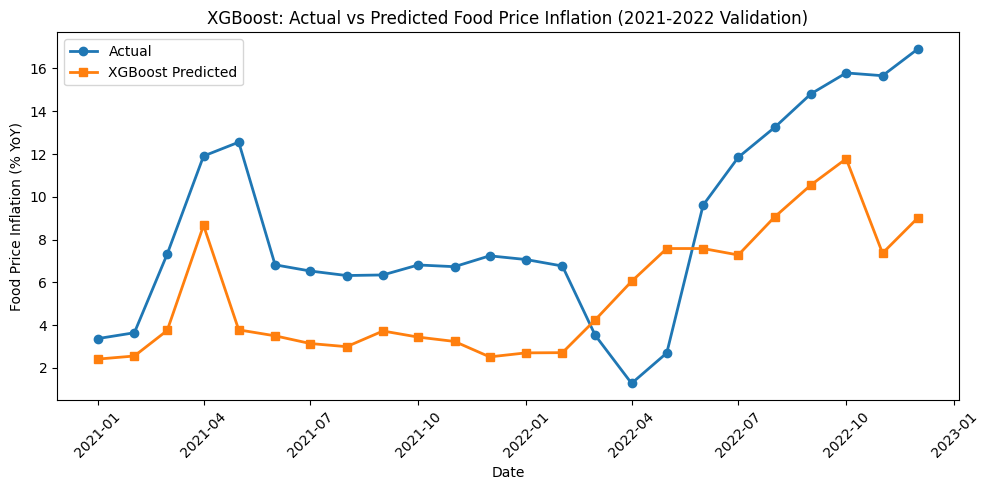

In [11]:
import matplotlib.pyplot as plt
import os

os.makedirs('../outputs/figures', exist_ok=True)

# ------------------------------------------------------------
# 1. XGBoost: Actual vs Predicted (validation period)
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(val['year_month'], val[target_col], marker='o', label='Actual', linewidth=2)
plt.plot(val['year_month'], val_preds, marker='s', label='XGBoost Predicted', linewidth=2)
plt.title('XGBoost: Actual vs Predicted Food Price Inflation (2021-2022 Validation)')
plt.xlabel('Date')
plt.ylabel('Food Price Inflation (% YoY)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_actual_vs_predicted.png', dpi=150)
plt.show()

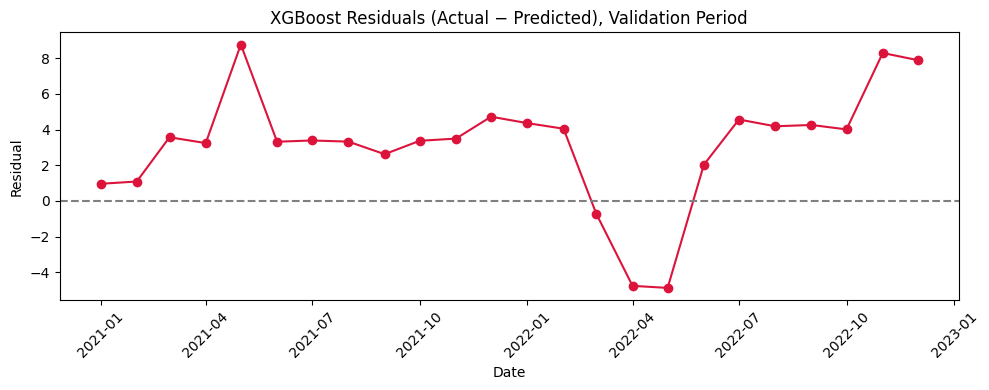

In [12]:
# ------------------------------------------------------------
# 2. XGBoost: Residuals over time
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(val['year_month'], residuals, marker='o', color='crimson')
plt.axhline(0, color='gray', linestyle='--')
plt.title('XGBoost Residuals (Actual − Predicted), Validation Period')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_residuals.png', dpi=150)
plt.show()

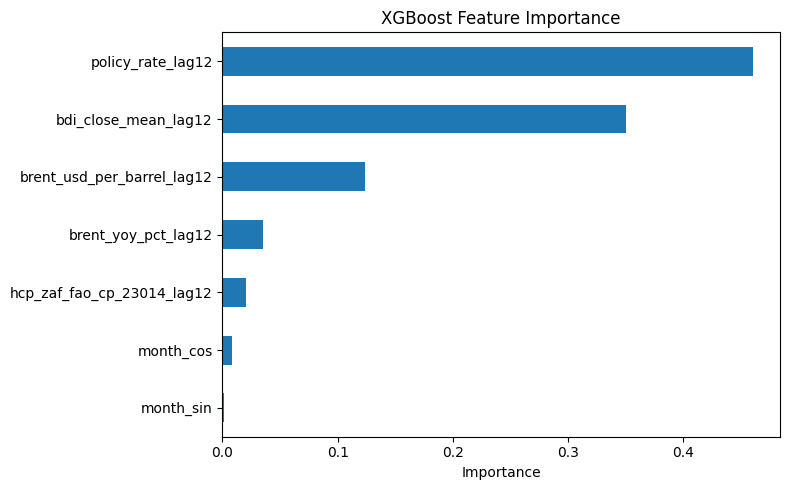

In [13]:
# ------------------------------------------------------------
# 3. Feature importance bar chart
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_feature_importance.png', dpi=150)
plt.show()

## Version 2

In [14]:
# load data — use the final feature set produced by 02_feature_engineering.ipynb
df_clean = pd.read_csv('../data/processed/model_ready_data.csv', parse_dates=['year_month'])
df_clean = df_clean.sort_values('year_month').reset_index(drop=True)

target_col = 'target_food_price_inflation'
exog_cols = [
    'hcp_zaf_fao_cp_23014_lag12',
    'brent_yoy_pct_lag12',
    'brent_usd_per_barrel_lag12',
    'bdi_close_mean_lag12',
    'month_sin',
    'month_cos'
]

In [15]:
# 2. Train / validation split

train = df_clean[(df_clean['year_month'] >= '2001-01-01') & (df_clean['year_month'] <= '2020-12-31')].reset_index(drop=True)
val   = df_clean[(df_clean['year_month'] >= '2021-01-01') & (df_clean['year_month'] <= '2022-12-31')].reset_index(drop=True)

In [16]:
# 3. Fit final model — hyperparameters selected via TimeSeriesSplit search

best_params = {
    'max_depth': 4,
    'learning_rate': 0.01,
    'n_estimators': 300,
    'subsample': 1.0,
    'colsample_bytree': 1.0,
    'reg_alpha': 0,
    'reg_lambda': 1.0
}

model = XGBRegressor(**best_params, random_state=42)
model.fit(train[exog_cols], train[target_col])


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
# 4. Evaluate on validation

val_preds = model.predict(val[exog_cols])
val_rmse = np.sqrt(mean_squared_error(val[target_col], val_preds))
val_mae = mean_absolute_error(val[target_col], val_preds)
print(f"Validation RMSE: {val_rmse:.4f}  MAE: {val_mae:.4f}")

residuals = val[target_col].values - val_preds
lb = acorr_ljungbox(residuals, lags=[12], return_df=True)
print("\nLjung-Box on residuals:")
print(lb)

importance = pd.Series(model.feature_importances_, index=exog_cols).sort_values(ascending=False)
print("\nFeature importance:")
print(importance)

Validation RMSE: 4.3552  MAE: 3.8926

Ljung-Box on residuals:
      lb_stat  lb_pvalue
12  20.185528   0.063657

Feature importance:
bdi_close_mean_lag12          0.633989
brent_usd_per_barrel_lag12    0.248472
brent_yoy_pct_lag12           0.062512
hcp_zaf_fao_cp_23014_lag12    0.036203
month_cos                     0.015502
month_sin                     0.003321
dtype: float32


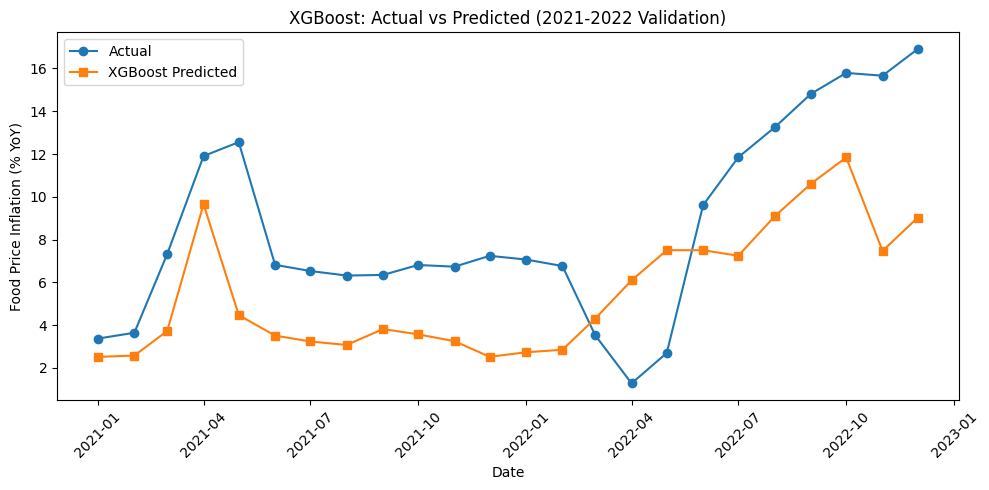

In [18]:
# plots

plt.figure(figsize=(10, 5))
plt.plot(val['year_month'], val[target_col], marker='o', label='Actual')
plt.plot(val['year_month'], val_preds, marker='s', label='XGBoost Predicted')
plt.title('XGBoost: Actual vs Predicted (2021-2022 Validation)')
plt.xlabel('Date'); plt.ylabel('Food Price Inflation (% YoY)')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_actual_vs_predicted.png', dpi=150)
plt.show()

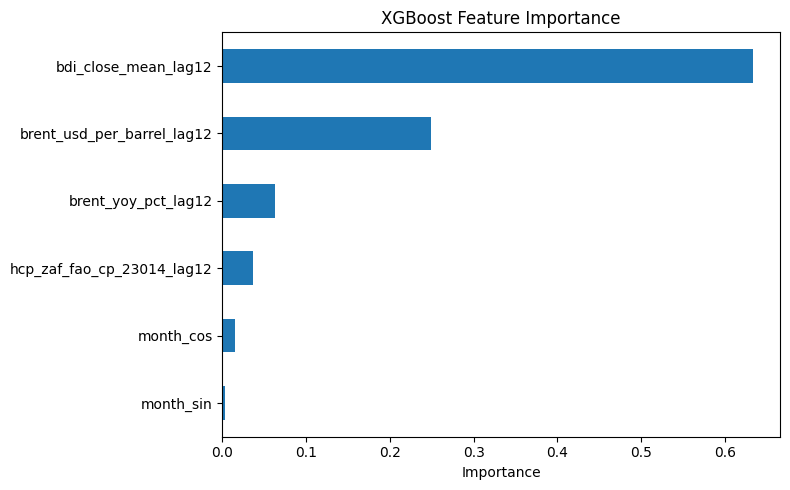

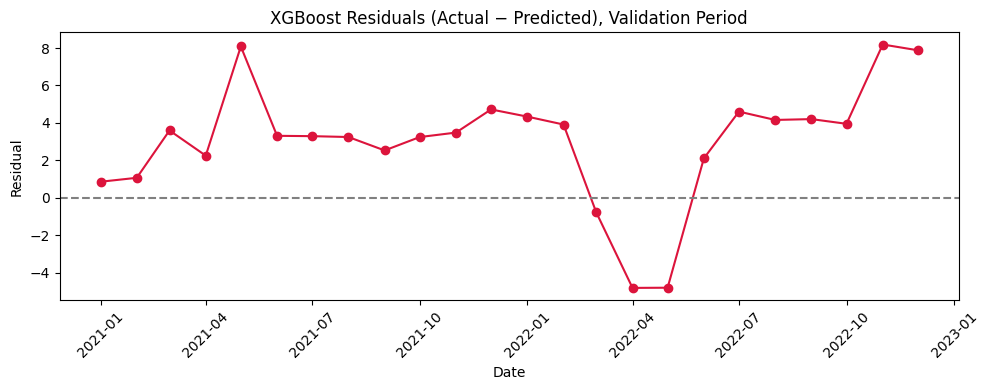

In [19]:
plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance'); plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_feature_importance.png', dpi=150)
plt.show()
# ------------------------------------------------------------
# XGBoost residuals over time
# ------------------------------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(val['year_month'], residuals, marker='o', color='crimson')
plt.axhline(0, color='gray', linestyle='--')
plt.title('XGBoost Residuals (Actual − Predicted), Validation Period')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_residuals.png', dpi=150)
plt.show()


---
**➜ Next: `04_model_dnn.ipynb`** 